### Build a Basic Chatbot with LangGraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    ## add_messages would append inside the list rather replacing them
    messages:Annotated[list,add_messages]

In [3]:
graph_builder=StateGraph(State)

In [4]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq

In [7]:
llm=ChatGroq(model='qwen/qwen3-32b')

In [8]:
llm.invoke("hii")

AIMessage(content='<think>\nOkay, the user said "hii". Let me think about how to respond.\n\nFirst, I should acknowledge their greeting. Maybe say hello back. They might be looking for a friendly conversation.\n\nI need to keep it open-ended so they feel comfortable to talk more. Maybe ask how they\'re doing or if they need help with something.\n\nWait, sometimes people just say hi to start a chat without a specific question. So I should offer assistance in case they have one.\n\nAlso, make sure the tone is warm and approachable. Avoid being too formal. Use an emoji maybe to keep it light.\n\nCheck for any typos in the response. Let me put that together.\n</think>\n\nHi there! 😊 How can I assist you today? Whether you have a question, need help with something, or just want to chat, I\'m here!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 174, 'prompt_tokens': 10, 'total_tokens': 184, 'completion_time': 0.411728477, 'completion_tokens_details': None, 'p

In [9]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [10]:
graph_builder=StateGraph(State)

graph_builder.add_node("chatbot",chatbot)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph=graph_builder.compile()

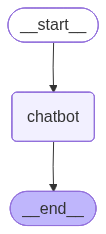

In [11]:
## Visulise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
graph.invoke({"messages":"Hii"})["messages"][-1].content

'<think>\nOkay, the user just said "Hii". Let me think about how to respond. First, they might have made a typo with the extra \'i\'. I should acknowledge that in a friendly way. Maybe say something like "Hi there!" to be welcoming. Then, offer assistance to show I\'m here to help. Keep it simple and positive. I don\'t want to overcomplicate the response. Let me check if there\'s anything else needed. No, that should cover it. Alright, time to put it all together.\n</think>\n\nHi there! 😊 How can I assist you today?'

In [13]:
for event in graph.stream({"messages":"Hi How are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me with "Hi, How are you?" So I should respond in a friendly and warm manner. First, I need to acknowledge their greeting and show that I'm here and ready to help. I can say something like "Hello! I'm doing well, thank you for asking! How can I assist you today?" That way, it opens the door for them to ask questions or share what they need help with. I should keep the tone positive and encouraging. I should also make sure to use proper punctuation and capitalization to maintain a professional yet approachable image. Let me check if there's anything else I should consider. Maybe add an emoji to make it friendlier? Hmm, but the user didn't use one, so maybe it's better to keep it simple and just focus on being clear and helpful. Alright, that should cover it.
</think>

Hello! I'm doing well, thank you for asking! How can I assist you today? 😊


### Chatbot with tools


In [14]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [15]:
## Custom function

def multiply(a:int,b:int)->int:
    """
    Multiply a and b

    Args:
        a (int): first number
        b (int): second number
    
    Returns:
        int: output Number
    """
    return a*b;

In [16]:
tools=[tool,multiply]

In [17]:
llm_with_tool=llm.bind_tools(tools)

In [18]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [19]:
builder=StateGraph(State)

In [20]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

In [21]:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

In [22]:
graph=builder.compile()

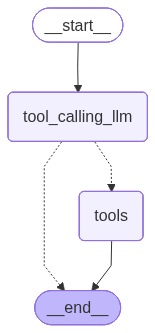

In [23]:
## Visulise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
response=graph.invoke({"messages":"What is the recent AI news"})

In [27]:
response["messages"][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.csoonline.com/article/4180316/ai-may-finally-unlock-the-cyber-budgets-cisos-have-wanted-for-years.html", "title": "AI may finally unlock the cyber budgets CISOs have wanted for years - csoonline.com", "score": 0.6739866, "published_date": "Wed, 03 Jun 2026 00:00:00 GMT", "content": "Jun 2, 2026 8 mins\\n news analysis\\n\\n  ### What happens when China’s AI catches up to Mythos?\\n\\n  May 13, 2026 6 mins\\n feature\\n\\n  ### Poisoned truth: The quiet security threat inside enterprise AI\\n\\n  May 6, 2026 10 mins\\n news\\n\\n  ### CISA pushes critical infrastructure operators to prepare to work in isolation\\n\\n  May 5, 2026 6 mins\\n news\\n\\n  ### Anthropic Mythos spurs White House to weigh pre-release reviews for high-risk AI models\\n\\n  May 4, 2026 4 mins\\n news\\n\\n  ### New US House privacy bills raise hard questions about enterprise data collection\\n\\n  Ap

In [29]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f096nvwxz)
 Call ID: f096nvwxz
  Args:
    query: AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.csoonline.com/article/4180316/ai-may-finally-unlock-the-cyber-budgets-cisos-have-wanted-for-years.html", "title": "AI may finally unlock the cyber budgets CISOs have wanted for years - csoonline.com", "score": 0.6739866, "published_date": "Wed, 03 Jun 2026 00:00:00 GMT", "content": "Jun 2, 2026 8 mins\n news analysis\n\n  ### What happens when China’s AI catches up to Mythos?\n\n  May 13, 2026 6 mins\n feature\n\n  ### Poisoned truth: The q

In [30]:
response=graph.invoke({"messages":"What is 2 multiplied by 3"})

In [31]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (59y9n3hhd)
 Call ID: 59y9n3hhd
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
